# Bates-Calibrated SPY Extension

This notebook builds a **Bates model** extension (Heston + jumps) on top of the Table 2 workflow:

1. Pull real SPY option quotes,
2. calibrate Bates parameters to market call mids across maturities,
3. simulate Bates Monte Carlo paths,
4. compare hedging performance of:
   - Black-Scholes delta benchmark,
   - Classical LSTM,
   - Augmented LSTM.

This keeps the paper-style simulation/training structure while using market-informed dynamics with jump risk.

In [11]:
import os, sys, json, math
from dataclasses import dataclass
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

try:
    import yfinance as yf
except Exception:
    yf = None

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.experiment import Config, run_experiment, report_table
from src.architectures import ClassicalLSTM, AugmentedLSTM
from src.payoffs import call_payoff
from src.simulators import compute_norm_stats

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
torch.manual_seed(42)
print('Device:', DEVICE)
print('yfinance available:', yf is not None)

Device: cpu
yfinance available: True


## 1) Market snapshot and calibration basket

In [12]:
if yf is None:
    raise RuntimeError('yfinance is required. Install with: uv sync --extra notebook')

tk = yf.Ticker('SPY')
spot = float(tk.history(period='1d', interval='1d', auto_adjust=False)['Close'].iloc[-1])

expiries = list(tk.options)
if not expiries:
    raise RuntimeError('No SPY expiries returned by yfinance.')

now = datetime.now(timezone.utc)

# Choose multiple maturities for calibration (surface fit), not just one expiry.
max_expiries = 5
strikes_per_expiry = 16
selected_expiries = []
for e in expiries:
    dt = datetime.fromisoformat(e).replace(tzinfo=timezone.utc)
    if (dt - now).days >= 14:
        selected_expiries.append(e)
    if len(selected_expiries) >= max_expiries:
        break
if not selected_expiries:
    raise RuntimeError('No suitable expiries >=14 days found.')

# Hedge horizon still needs a single expiry; use nearest selected one.
hedge_expiry = selected_expiries[0]
hedge_expiry_dt = datetime.fromisoformat(hedge_expiry).replace(tzinfo=timezone.utc)
T_HEDGE = max((hedge_expiry_dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)

# Build calibration quotes across maturities (near-ATM + liquid).
quote_rows = []
for e in selected_expiries:
    dt = datetime.fromisoformat(e).replace(tzinfo=timezone.utc)
    tau = max((dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)

    ch = tk.option_chain(e).calls.copy()
    ch = ch[(ch['bid'] > 0) & (ch['ask'] > 0) & (ch['strike'] > 0)].copy()
    if ch.empty:
        continue

    ch['mid'] = 0.5 * (ch['bid'] + ch['ask'])
    ch['mny_dist'] = np.abs(ch['strike'] / spot - 1.0)
    # prioritize tighter spreads and near ATM
    ch['spread'] = np.maximum(ch['ask'] - ch['bid'], 1e-6)
    ch = ch.sort_values(['mny_dist', 'spread']).head(strikes_per_expiry).copy()

    ch['expiry'] = e
    ch['tau'] = tau
    quote_rows.append(ch[['expiry', 'tau', 'strike', 'bid', 'ask', 'mid', 'spread']])

if not quote_rows:
    raise RuntimeError('Failed to build multi-maturity calibration basket.')

quotes = pd.concat(quote_rows, ignore_index=True)
quotes = quotes.sort_values(['tau', 'strike']).reset_index(drop=True)
quotes['weight'] = 1.0 / np.maximum(quotes['spread'], 0.05)
quotes['weight'] = quotes['weight'] / quotes['weight'].mean()

print(f'Spot={spot:.2f}')
print(f'Calibration expiries: {selected_expiries}')
print(f'Hedge expiry={hedge_expiry}, T_HEDGE={T_HEDGE:.4f} years')
print(f'Calibration quotes: {len(quotes)} total')

Spot=709.48
Calibration expiries: ['2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18']
Hedge expiry=2026-05-08, T_HEDGE=0.0554 years
Calibration quotes: 80 total


## 2) Bates Monte Carlo pricer and calibration

We calibrate parameters `(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ)` by minimizing weighted call price MSE across maturities.

In [ ]:
def simulate_bates_terminal(
    S0, T, n_steps, n_paths,
    kappa, theta, xi, rho, v0,
    lambdaJ, muJ, sigmaJ,
    r=0.0, seed=123,
):
    """Bates process: Heston stochastic variance + compound Poisson lognormal jumps."""
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=np.float64)
    v = np.full(n_paths, max(v0, 1e-8), dtype=np.float64)

    sqdt = math.sqrt(dt)
    rho2 = math.sqrt(max(1.0 - rho * rho, 1e-12))

    # jump compensator for risk-neutral drift
    kJ = math.exp(muJ + 0.5 * sigmaJ * sigmaJ) - 1.0

    for _ in range(n_steps):
        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)
        dW1 = sqdt * z1
        dW2 = sqdt * (rho * z1 + rho2 * z2)

        v_pos = np.maximum(v, 0.0)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos + 1e-12) * dW2
        v = np.maximum(v, 1e-10)

        # Diffusion part with jump compensator in drift.
        log_ret_diff = (r - lambdaJ * kJ - 0.5 * v_pos) * dt + np.sqrt(v_pos + 1e-12) * dW1

        # Jump part: N~Poisson(lambda dt), each jump log-size ~ N(muJ, sigmaJ^2)
        Np = rng.poisson(lambdaJ * dt, size=n_paths)
        jump_log = np.zeros(n_paths, dtype=np.float64)
        idx = np.where(Np > 0)[0]
        for ii in idx:
            jump_log[ii] = rng.normal(loc=muJ * Np[ii], scale=sigmaJ * math.sqrt(Np[ii]))

        S = S * np.exp(log_ret_diff + jump_log)

    return S


def bates_call_prices_mc(S0, K_array, T, params, n_steps=40, n_paths=25000, seed=123):
    ST = simulate_bates_terminal(
        S0=S0, T=T, n_steps=n_steps, n_paths=n_paths,
        kappa=params[0], theta=params[1], xi=params[2], rho=params[3], v0=params[4],
        lambdaJ=params[5], muJ=params[6], sigmaJ=params[7],
        seed=seed,
    )
    payoff = np.maximum(ST[:, None] - K_array[None, :], 0.0)
    return payoff.mean(axis=0)


def bates_surface_prices_mc(quotes_df, params, n_steps=40, n_paths=12000, seed=123):
    out = np.zeros(len(quotes_df), dtype=float)
    for i, (tau, g) in enumerate(quotes_df.groupby('tau', sort=True)):
        K_arr = g['strike'].to_numpy(dtype=float)
        model = bates_call_prices_mc(
            S0=spot,
            K_array=K_arr,
            T=float(tau),
            params=params,
            n_steps=max(6, int(round(n_steps * float(tau) / max(T_HEDGE, 1e-6)))),
            n_paths=n_paths,
            seed=seed + i,
        )
        out[g.index.to_numpy()] = model
    return out


def calib_objective(x):
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ = x
    if theta <= 0 or xi <= 0 or v0 <= 0 or kappa <= 0 or abs(rho) >= 0.999:
        return 1e9
    if lambdaJ < 0 or sigmaJ <= 0:
        return 1e9

    feller_pen = max(0.0, xi * xi - 2.0 * kappa * theta)

    model = bates_surface_prices_mc(
        quotes_df=quotes,
        params=x,
        n_steps=40,
        n_paths=7000,
        seed=777,
    )
    y = quotes['mid'].to_numpy(dtype=float)
    w = quotes['weight'].to_numpy(dtype=float)
    err = w * (model - y) ** 2
    return float(err.mean() + 10.0 * feller_pen)


bounds = [
    (0.2, 8.0),      # kappa
    (0.005, 0.20),   # theta
    (0.05, 1.20),    # xi
    (-0.95, -0.05),  # rho
    (0.005, 0.25),   # v0
    (0.0, 8.0),      # lambdaJ
    (-0.20, 0.05),   # muJ (downward jumps usually negative)
    (0.02, 0.60),    # sigmaJ
]

print('Running multi-maturity Bates calibration (this can take a few minutes)...')
res = differential_evolution(
    calib_objective,
    bounds=bounds,
    maxiter=20,
    popsize=10,
    seed=42,
    polish=False,
    disp=True,
)

kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ = [float(v) for v in res.x]
print('\nCalibrated params:')
print(f'kappa={kappa:.4f}, theta={theta:.4f}, xi={xi:.4f}, rho={rho:.4f}, v0={v0:.4f}')
print(f'lambdaJ={lambdaJ:.4f}, muJ={muJ:.4f}, sigmaJ={sigmaJ:.4f}')
print(f'Objective={res.fun:.6e}')

quotes = quotes.copy()
quotes['model_price'] = bates_surface_prices_mc(
    quotes_df=quotes,
    params=(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ),
    n_steps=60,
    n_paths=24000,
    seed=2026,
)
fit_mse = float(np.mean((quotes['model_price'].to_numpy() - quotes['mid'].to_numpy()) ** 2))
print(f'Post-calibration surface MSE={fit_mse:.3e}')

Running multi-maturity Bates calibration (this can take a few minutes)...


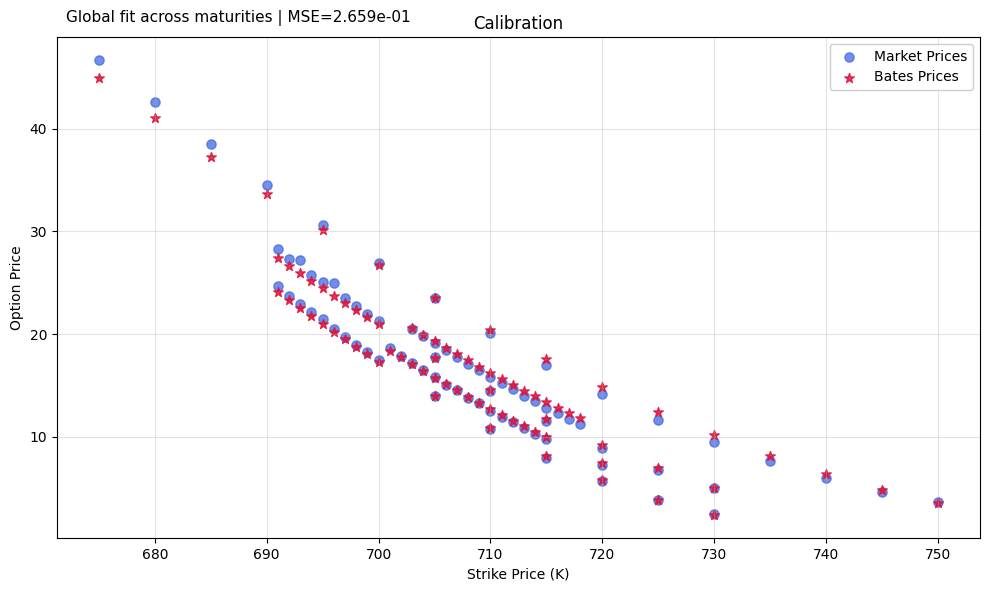

In [ ]:
# Calibration scatter like your reference figure: one global view across all maturities.
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.scatter(
    quotes['strike'],
    quotes['mid'],
    s=44,
    color='royalblue',
    alpha=0.75,
    label='Market Prices',
)
ax.scatter(
    quotes['strike'],
    quotes['model_price'],
    s=52,
    marker='*',
    color='crimson',
    alpha=0.85,
    label='Bates Prices',
)

mse_global = float(np.mean((quotes['model_price'] - quotes['mid']) ** 2))
ax.set_title('Calibration')
ax.text(
    0.01,
    1.03,
    f'Global fit across maturities | MSE={mse_global:.3e}',
    transform=ax.transAxes,
    fontsize=11,
)
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Option Price')
ax.grid(alpha=0.35)
ax.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

## 2b) Implied-vol surface view: market BS IV vs Bates-fitted IV

Blue dots = market-implied vols (from option mids via BS inversion).  
Orange crosses = implied vols of Bates-fitted model prices.

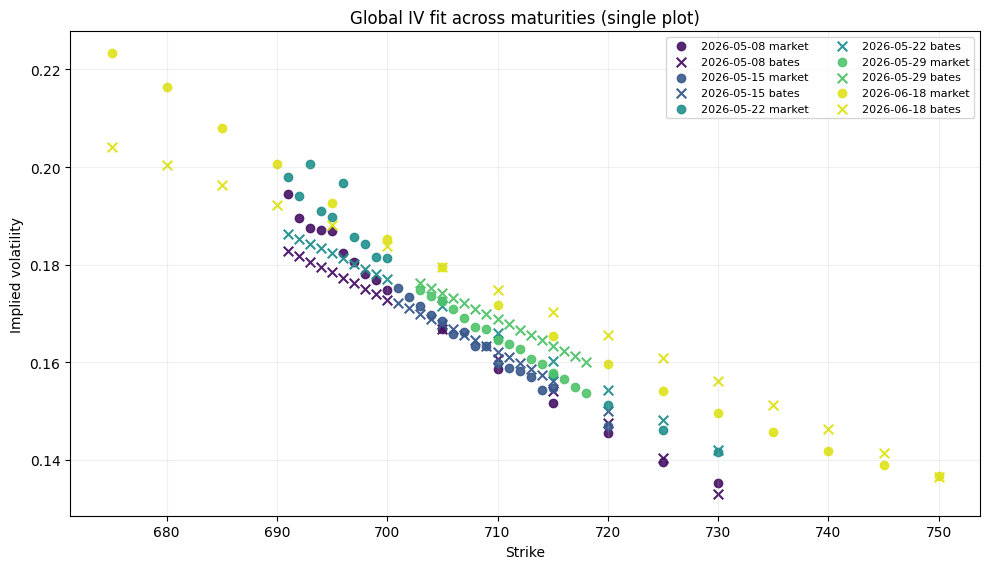

In [ ]:
def bs_call_price_r(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    cdf = lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
    return S * cdf(d1) - K * math.exp(-r * T) * cdf(d2)


def implied_vol_from_call(price, S, K, T, r=0.0):
    intrinsic = max(S - K * math.exp(-r * T), 0.0)
    # Clamp tiny numerical violations from MC noise.
    p = min(max(float(price), intrinsic + 1e-10), S)

    lo, hi = 1e-4, 5.0
    for _ in range(100):
        mid = 0.5 * (lo + hi)
        pmid = bs_call_price_r(S, K, T, mid, r=r)
        if pmid > p:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


iv_df = quotes.copy()
iv_df['iv_market'] = [implied_vol_from_call(p, spot, k, t) for p, k, t in zip(iv_df['mid'], iv_df['strike'], iv_df['tau'])]
iv_df['iv_bates'] = [implied_vol_from_call(p, spot, k, t) for p, k, t in zip(iv_df['model_price'], iv_df['strike'], iv_df['tau'])]

# Single global plot across maturities:
# color = maturity (tau), marker = source (dot market / cross bates).
fig, ax = plt.subplots(1, 1, figsize=(10, 5.8))

uniq_exp = list(iv_df['expiry'].drop_duplicates())
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(uniq_exp)))

for c, exp_i in zip(colors, uniq_exp):
    g = iv_df[iv_df['expiry'] == exp_i].sort_values('strike')
    ax.scatter(g['strike'], g['iv_market'], marker='o', s=36, color=c, alpha=0.9, label=f'{exp_i} market')
    ax.scatter(g['strike'], g['iv_bates'], marker='x', s=48, color=c, alpha=0.95, label=f'{exp_i} bates')

ax.set_title('Global IV fit across maturities (single plot)')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied volatility')
ax.grid(alpha=0.2)

# Deduplicate legend entries and keep compact formatting.
handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        uniq_h.append(h)
        uniq_l.append(l)
ax.legend(uniq_h, uniq_l, fontsize=8, ncol=2, loc='best')

plt.tight_layout()
plt.show()

## 3) Simulate calibrated Bates paths for hedging experiments

In [ ]:
def simulate_bates_paths_torch(
    n_paths, S0, T, N, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=0, device='cpu'
):
    dt = T / N
    sqdt = math.sqrt(dt)
    gen = torch.Generator(device=device).manual_seed(seed)

    S = torch.full((n_paths,), float(S0), dtype=torch.float32, device=device)
    v = torch.full((n_paths,), float(max(v0, 1e-8)), dtype=torch.float32, device=device)

    out = torch.zeros((n_paths, N + 1), dtype=torch.float32, device=device)
    out[:, 0] = S

    rho2 = math.sqrt(max(1.0 - rho * rho, 1e-12))
    kJ = math.exp(muJ + 0.5 * sigmaJ * sigmaJ) - 1.0

    for j in range(N):
        z1 = torch.randn((n_paths,), generator=gen, device=device)
        z2 = torch.randn((n_paths,), generator=gen, device=device)
        dW1 = sqdt * z1
        dW2 = sqdt * (rho * z1 + rho2 * z2)

        v_pos = torch.clamp(v, min=0.0)
        v = v + kappa * (theta - v_pos) * dt + xi * torch.sqrt(v_pos + 1e-10) * dW2
        v = torch.clamp(v, min=1e-10)

        # Poisson jump count and aggregated log jump per step
        Np = torch.poisson(torch.full((n_paths,), lambdaJ * dt, device=device))
        jump = torch.zeros(n_paths, device=device)
        idx = Np > 0
        if torch.any(idx):
            jump[idx] = muJ * Np[idx] + sigmaJ * torch.sqrt(Np[idx]) * torch.randn((int(idx.sum().item()),), generator=gen, device=device)

        S = S * torch.exp((-(lambdaJ * kJ) - 0.5 * v_pos) * dt + torch.sqrt(v_pos + 1e-10) * dW1 + jump)
        out[:, j + 1] = S

    return out

N_HEDGE = max(int(round(T_HEDGE * 365)), 5)
# ATM strike for hedge target from the hedge expiry subset.
hedge_quotes = quotes[quotes['expiry'] == hedge_expiry].copy()
K_ATM = float(hedge_quotes.iloc[np.argmin(np.abs(hedge_quotes['strike'].to_numpy() - spot))]['strike'])

print(f'N_HEDGE={N_HEDGE}, hedge_expiry={hedge_expiry}, K_ATM={K_ATM:.2f}')

N_HEDGE=20, hedge_expiry=2026-05-08, K_ATM=710.00


## 4) Black-Scholes delta hedge benchmark on Bates paths

In [ ]:
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_call_price(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * norm_cdf(d2)

def bs_delta_np(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return np.where(S > K, 1.0, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return 0.5 * (1.0 + np.vectorize(math.erf)(d1 / np.sqrt(2.0)))

# Use sqrt(theta) as BS benchmark vol from calibrated Bates long-run variance.
sigma_bs = float(math.sqrt(max(theta, 1e-8)))

paths_eval_np = simulate_bates_paths_torch(
    n_paths=30000, S0=spot, T=T_HEDGE, N=N_HEDGE,
    kappa=kappa, theta=theta, xi=xi, rho=rho, v0=v0,
    lambdaJ=lambdaJ, muJ=muJ, sigmaJ=sigmaJ,
    seed=55, device='cpu'
).cpu().numpy()

n_steps = paths_eval_np.shape[1] - 1
dt = T_HEDGE / n_steps

p0 = bs_call_price(spot, K_ATM, T_HEDGE, sigma_bs)
S0 = paths_eval_np[:, 0]
d_prev = bs_delta_np(S0, K_ATM, T_HEDGE, sigma_bs)
cash = np.full(paths_eval_np.shape[0], p0) - d_prev * S0

for t in range(1, n_steps + 1):
    tau = max(T_HEDGE - t * dt, 0.0)
    St = paths_eval_np[:, t]
    d_new = bs_delta_np(St, K_ATM, tau, sigma_bs) if t < n_steps else np.zeros_like(St)
    cash -= (d_new - d_prev) * St
    d_prev = d_new

payoff = np.maximum(paths_eval_np[:, -1] - K_ATM, 0.0)
portfolio_T = cash + d_prev * paths_eval_np[:, -1]
Y_bs = portfolio_T - payoff
mse_bs = float(np.mean(Y_bs**2))
print(f'BS benchmark sigma={sigma_bs:.4f} | MSE={mse_bs:.3e} | mean={np.mean(Y_bs):.3e} | std={np.std(Y_bs):.3e}')

BS benchmark sigma=0.2560 | MSE=5.453e+01 | mean=6.399e+00 | std=3.686e+00


## 5) Table 2-style NN hedging on calibrated Bates data

In [ ]:
QUICK = False
if QUICK:
    N_ITER = 700
    N_TRAIN = 25000
    N_EVAL = 10000
    N_NORM = 10000
else:
    N_ITER = 3000
    N_TRAIN = 60000
    N_EVAL = 25000
    N_NORM = 25000

BATCH = 50
LR = 1e-3


def make_bates_paths():
    tr = simulate_bates_paths_torch(N_TRAIN, spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=101, device='cpu').unsqueeze(-1)
    ev = simulate_bates_paths_torch(N_EVAL,  spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=102, device='cpu').unsqueeze(-1)
    rf = simulate_bates_paths_torch(N_NORM,  spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=999, device='cpu').unsqueeze(-1)
    mean, std = compute_norm_stats(rf)
    return tr, ev, mean, std

cfg_bates = Config(
    name='Bates SPY call',
    d=1,
    N=N_HEDGE,
    paths_factory=make_bates_paths,
    payoff_fn=lambda p: call_payoff(p[:, -1, 0], K=K_ATM),
    arch_factory={
        'Classical LSTM': lambda: ClassicalLSTM(N=N_HEDGE, d=1, hidden=50),
        'Augmented LSTM': lambda: AugmentedLSTM(N=N_HEDGE, d=1, hidden=50, ff_width=10, ff_layers=3),
    },
    n_iter=N_ITER,
    batch_size=BATCH,
    lr=LR,
    paper_values={},
)

print(f'N={N_HEDGE}, iter={N_ITER}, train/eval/norm={N_TRAIN}/{N_EVAL}/{N_NORM}')
res_bates = run_experiment(cfg_bates, device=DEVICE)

mock_cfg = type('Cfg', (), {'paper_values': {}})()
comparison = {
    'Bates calibrated test': {
        'cfg': mock_cfg,
        'mse': {
            'BS delta benchmark': mse_bs,
            'Classical LSTM': float(res_bates['mse']['Classical LSTM']),
            'Augmented LSTM': float(res_bates['mse']['Augmented LSTM']),
        }
    }
}

report_table(comparison, title='BATES CALIBRATED: BS VS LSTM')

N=20, iter=3000, train/eval/norm=60000/25000/25000


Bates SPY call:Augmented LSTM: 100%|██████████| 3000/3000 [01:40<00:00, 29.82it/s]


  BATES CALIBRATED: BS VS LSTM
  Experiment              Model                        Our MSE     Paper MSE       Ratio
--------------------------------------------------------------------------------------
  Bates calibrated test   BS delta benchmark         5.453e+01             —           —
  Bates calibrated test   Classical LSTM             1.030e+02             —           —
  Bates calibrated test   Augmented LSTM             1.083e+02             —           —


In [ ]:
OUT = os.path.join(ROOT, 'results_bates')
os.makedirs(OUT, exist_ok=True)
summary = {
    'meta': {
        'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        'spot': float(spot),
        'calibration_expiries': selected_expiries,
        'hedge_expiry': hedge_expiry,
        'T_hedge_years': float(T_HEDGE),
        'K_atm': float(K_ATM),
        'N_hedge': int(N_HEDGE),
        'device': DEVICE,
    },
    'bates_params': {
        'kappa': float(kappa),
        'theta': float(theta),
        'xi': float(xi),
        'rho': float(rho),
        'v0': float(v0),
        'lambdaJ': float(lambdaJ),
        'muJ': float(muJ),
        'sigmaJ': float(sigmaJ),
    },
    'calibration': {
        'objective': float(res.fun),
        'surface_mse': float(fit_mse),
        'n_quotes': int(len(quotes)),
    },
    'hedging_mse': {
        'BS delta benchmark': float(mse_bs),
        'Classical LSTM': float(res_bates['mse']['Classical LSTM']),
        'Augmented LSTM': float(res_bates['mse']['Augmented LSTM']),
    },
}
sp = os.path.join(OUT, 'bates_spy_summary.json')
with open(sp, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print('Saved:', sp)

Saved: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_spy_summary.json


## 6) Paper-style liquidity + transaction-cost Pareto training (Eq. 22)

We now follow Section 7 of the paper in the Bates market:

- fixed premium `p = E[g(S_T)]` (not optimized),
- proportional transaction costs `c` per traded unit,
- liquidity cap `liq` on per-step position change,
- one **Augmented LSTM** trained for all `alpha in [0,1]` by adding `alpha` to inputs,
- `alpha` sampled with a Sobol quasi-random generator each iteration.

Objective (paper Eq. 22):

`d_alpha = (1-alpha) E[TC] + alpha * sqrt(E[(X_T - g(S_T))^2])`

Premium fixed at E[g(S_T)] = 10.7932
iter    500/5000 | loss=4.3847e-01 | alpha~0.160
iter   1000/5000 | loss=1.5705e+00 | alpha~0.486
iter   1500/5000 | loss=1.8976e-01 | alpha~0.054
iter   2000/5000 | loss=1.0248e+00 | alpha~0.350
iter   2500/5000 | loss=6.8238e-01 | alpha~0.227
iter   3000/5000 | loss=9.8977e-01 | alpha~0.403
iter   3500/5000 | loss=2.8484e-01 | alpha~0.101
iter   4000/5000 | loss=6.9529e-01 | alpha~0.258
iter   4500/5000 | loss=3.9967e-01 | alpha~0.132
iter   5000/5000 | loss=1.4438e+00 | alpha~0.461


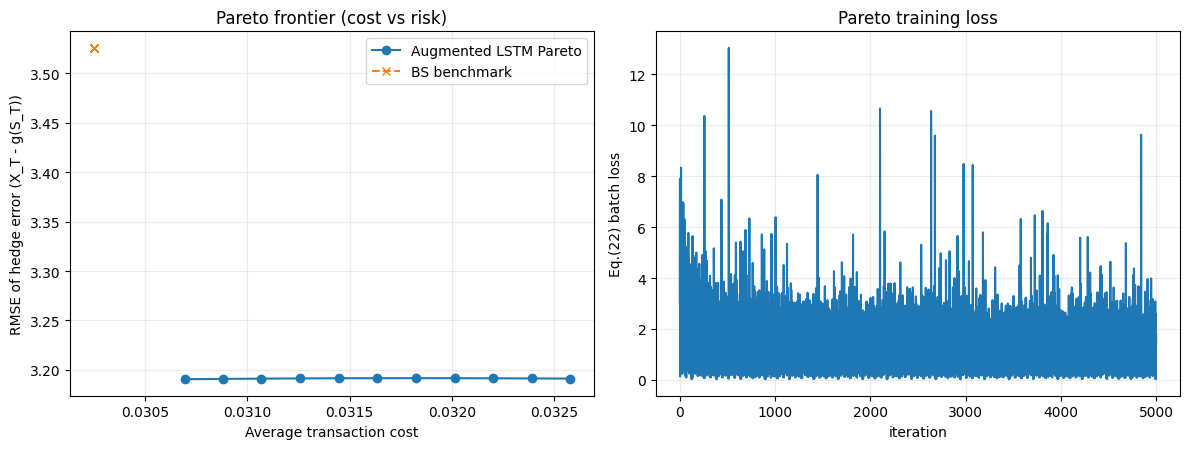

Saved: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_pareto_frontier.json


In [ ]:
from torch.quasirandom import SobolEngine

# --- configuration (paper-style but reduced for notebook runtime) ---
PARETO_ITERS = 5000          # paper uses 100k; increase if you want a tighter frontier
PARETO_BATCH = 64
PARETO_LR = 1e-3
PARETO_HIDDEN = 50
PARETO_FF_WIDTH = 50         # paper section 7 increases projection width to 50
PARETO_FF_LAYERS = 3

N_TRAIN_P = 70000
N_EVAL_P = 30000
N_NORM_P = 30000

TC_PER_UNIT = 0.02           # paper-style constant c_j
LIQ = 0.35                   # max per-step delta change (model units)

# --- build Bates datasets for Pareto run ---
train_raw = simulate_bates_paths_torch(
    N_TRAIN_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=310, device=DEVICE
).unsqueeze(-1)

eval_raw = simulate_bates_paths_torch(
    N_EVAL_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=311, device=DEVICE
).unsqueeze(-1)

ref_raw = simulate_bates_paths_torch(
    N_NORM_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=399, device=DEVICE
).unsqueeze(-1)

norm_mean, norm_std = compute_norm_stats(ref_raw)
train_norm = (train_raw - norm_mean) / norm_std
eval_norm = (eval_raw - norm_mean) / norm_std

# Fixed premium p = E[g(S_T)] on train set (paper section 7)
with torch.no_grad():
    payoff_train = call_payoff(train_raw[:, -1, 0], K=K_ATM)
    premium_fixed = float(payoff_train.mean().item())

print(f'Premium fixed at E[g(S_T)] = {premium_fixed:.4f}')

# Model with alpha as extra input (extra_in=1)
pareto_model = AugmentedLSTM(
    N=N_HEDGE, d=1, hidden=PARETO_HIDDEN,
    ff_width=PARETO_FF_WIDTH, ff_layers=PARETO_FF_LAYERS,
    extra_in=1,
).to(DEVICE)

# freeze premium at p and do not optimize it
with torch.no_grad():
    pareto_model.premium.fill_(premium_fixed)
pareto_model.premium.requires_grad_(False)

optimizer = torch.optim.Adam(
    [p for p in pareto_model.parameters() if p.requires_grad],
    lr=PARETO_LR,
)

sobol = SobolEngine(dimension=1, scramble=True, seed=2026)

train_hist = []
for it in range(PARETO_ITERS):
    idx = torch.randint(0, train_raw.shape[0], (PARETO_BATCH,), device=DEVICE)
    br = train_raw[idx]
    bn = train_norm[idx]

    alpha = sobol.draw(1).to(DEVICE).view(1).expand(PARETO_BATCH)

    out = pareto_model(br, bn, liq=LIQ, alpha=alpha, tc_cost=TC_PER_UNIT)
    g = call_payoff(br[:, -1, 0], K=K_ATM)

    # X_T and transaction costs for Eq. (22)
    X = out['pnl']
    tc = out['tc']
    err = X - g

    a = alpha.mean()
    loss = (1.0 - a) * tc.mean() + a * torch.sqrt((err ** 2).mean() + 1e-12)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(pareto_model.parameters(), 1.0)
    optimizer.step()

    train_hist.append(float(loss.item()))
    if (it + 1) % 500 == 0:
        print(f'iter {it+1:>6d}/{PARETO_ITERS} | loss={train_hist[-1]:.4e} | alpha~{float(a):.3f}')

# --- evaluate frontier for fixed alpha grid ---
def eval_pareto_point(model, alpha_value: float):
    with torch.no_grad():
        a = torch.full((eval_raw.shape[0],), float(alpha_value), device=DEVICE)
        out = model(eval_raw, eval_norm, liq=LIQ, alpha=a, tc_cost=TC_PER_UNIT)
        g = call_payoff(eval_raw[:, -1, 0], K=K_ATM)
        X = out['pnl']
        tc = out['tc']
        err = X - g
        rmse = torch.sqrt((err ** 2).mean())
        d_alpha = (1.0 - alpha_value) * tc.mean() + alpha_value * rmse
        Y = X - g - tc
        mseY = (Y ** 2).mean()
    return {
        'alpha': float(alpha_value),
        'mean_tc': float(tc.mean().item()),
        'rmse_err': float(rmse.item()),
        'criterion': float(d_alpha.item()),
        'mse_Y': float(mseY.item()),
    }

frontier = [eval_pareto_point(pareto_model, a) for a in np.linspace(0.0, 1.0, 11)]

# BS baseline under same liq+tc for comparison at each alpha
def bs_frontier_point(alpha_value: float):
    # Liquidity-capped BS delta rebalancing on the same eval paths
    P = eval_raw[:, :, 0].detach().cpu().numpy()
    n_paths = P.shape[0]
    n_steps = P.shape[1] - 1
    dt = T_HEDGE / n_steps

    # same fixed premium as in Pareto setup
    cash = np.full(n_paths, premium_fixed, dtype=float)
    delta_prev = np.zeros(n_paths, dtype=float)
    tc_paid = np.zeros(n_paths, dtype=float)

    for t in range(n_steps):
        tau = max(T_HEDGE - t * dt, 1e-8)
        St = P[:, t]
        d_target = bs_delta_np(St, K_ATM, tau, sigma_bs)
        # enforce liquidity cap on delta change
        d_new = delta_prev + np.clip(d_target - delta_prev, -LIQ, LIQ)
        trade = d_new - delta_prev
        tc_paid += TC_PER_UNIT * np.abs(trade)

        dS = P[:, t + 1] - St
        cash += d_new * dS
        delta_prev = d_new

    payoff = np.maximum(P[:, -1] - K_ATM, 0.0)
    X = cash
    err = X - payoff
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mean_tc = float(np.mean(tc_paid))
    d_alpha = (1.0 - alpha_value) * mean_tc + alpha_value * rmse
    Y = X - payoff - tc_paid
    mseY = float(np.mean(Y ** 2))

    return {
        'alpha': float(alpha_value),
        'mean_tc': mean_tc,
        'rmse_err': rmse,
        'criterion': float(d_alpha),
        'mse_Y': mseY,
    }

bs_frontier = [bs_frontier_point(a) for a in np.linspace(0.0, 1.0, 11)]

# --- plots ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].plot([p['mean_tc'] for p in frontier], [p['rmse_err'] for p in frontier], 'o-', label='Augmented LSTM Pareto')
ax[0].plot([p['mean_tc'] for p in bs_frontier], [p['rmse_err'] for p in bs_frontier], 'x--', label='BS benchmark')
ax[0].set_xlabel('Average transaction cost')
ax[0].set_ylabel('RMSE of hedge error (X_T - g(S_T))')
ax[0].set_title('Pareto frontier (cost vs risk)')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].plot(train_hist)
ax[1].set_title('Pareto training loss')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('Eq.(22) batch loss')
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# --- save ---
out = {
    'meta': {
        'model': 'AugmentedLSTM Pareto (Bates)',
        'premium_fixed': premium_fixed,
        'tc_per_unit': TC_PER_UNIT,
        'liq': LIQ,
        'n_iter': PARETO_ITERS,
        'n_train': N_TRAIN_P,
        'n_eval': N_EVAL_P,
    },
    'frontier_nn': frontier,
    'frontier_bs': bs_frontier,
}
os.makedirs(os.path.join(ROOT, 'results_bates'), exist_ok=True)
fp = os.path.join(ROOT, 'results_bates', 'bates_pareto_frontier.json')
with open(fp, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2)
print('Saved:', fp)